# ECE236A (Fall 2025)

This notebook shows **how to use** the provided `utils.py` and your `MySolution_{group_number}.py` for:
- **Task 1** (baseline classifier),
- **Task 2** (centralized compression),
- **Task 3.1** (per-sensor budget), **Task 3.2** (total budget), and
- **Task 3.3** (minimal bits for target accuracy).

It includes **commented-out** code blocks that you can enable after you implement your methods.
For now, we also include **mock results** to show the required plotting formats.

> **Important:** These cells are **guidelines**, not a complete solution. You may (and often should) adapt the code to:
> - output all required artifacts for the report (e.g., chosen allocations, validation choices, baselines),
> - plot additional figures that strengthen your analysis,
> - add helper functions/visualizations to support your arguments.
>
> This boilerplate demonstrates how to **wire up** the methods and plotting utilities. You’re responsible for producing all figures/results requested in the project handout.

In [1]:
from utils import *
from MySolution_2 import MyDecentralized, MyFeatureCompression, MyTargetAllocator
import scipy 
import matplotlib.pyplot as plt 
%load_ext autoreload
%autoreload 2

## Load datasets

Synthetic shapes: (800, 2) (800,)


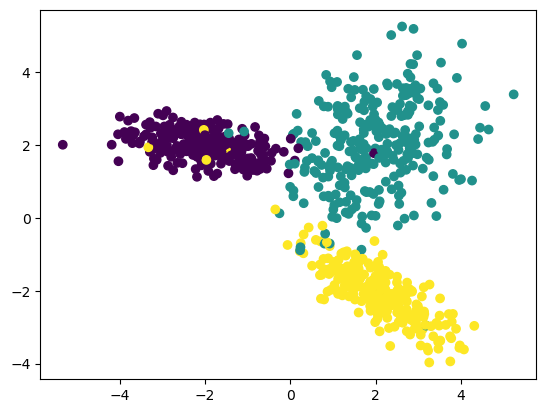

In [2]:
syn_data = prepare_synthetic_data()
print("Synthetic shapes:", syn_data['trainX'].shape, syn_data['trainY'].shape)
plt.scatter(syn_data['trainX'][:, 0], syn_data['trainX'][:, 1], c=syn_data['trainY']); plt.show()

MNIST shapes: (800, 784) (800,)


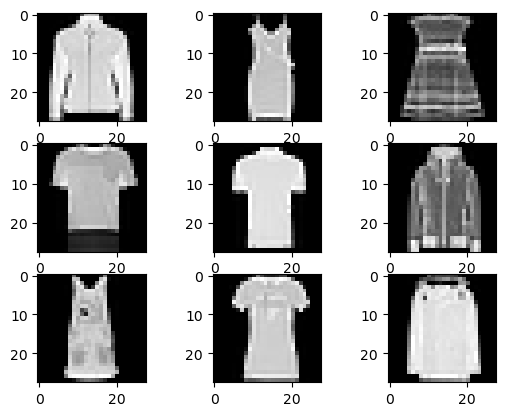

In [3]:
mnist_data = prepare_mnist_data()
print("MNIST shapes:", mnist_data['trainX'].shape, mnist_data['trainY'].shape)
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(mnist_data['trainX'][i].reshape(28,28), cmap='gray')
plt.show()

## Task 1 — Baseline classifier (Decentralized class, no compression)
Uncomment the following once you've implemented `MyDecentralized.train/predict/score`.

In [4]:
clf = MyDecentralized(K=3)
clf.train(syn_data['trainX'], syn_data['trainY'])  # if you need val, modify signature accordingly
syn_test_acc = clf.evaluate(syn_data['testX'], syn_data['testY'])
print("Task 1 test accuracy:", syn_test_acc)

clf = MyDecentralized(K=3)
clf.train(mnist_data['trainX'], mnist_data['trainY'])  # if you need val, modify signature accordingly
mnist_test_acc = clf.evaluate(mnist_data['testX'], mnist_data['testY'])
print("Task 1 test accuracy:", mnist_test_acc)

Task 1 test accuracy: 0.97
Task 1 test accuracy: 0.908


Text(0, 0.5, '% Accuracy')

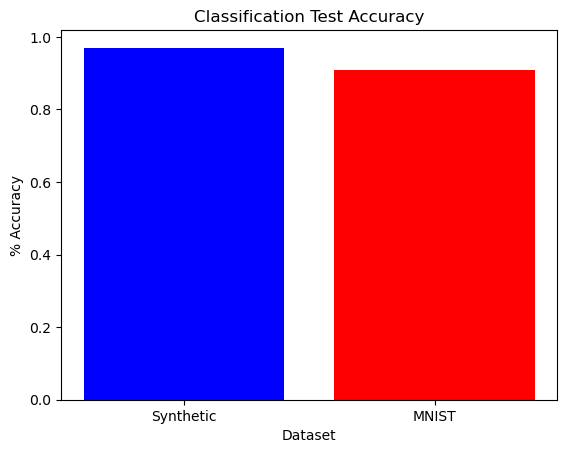

In [5]:
plt.bar(['Synthetic', 'MNIST'], [syn_test_acc, mnist_test_acc], color = [ 'blue','red'])
plt.title("Classification Test Accuracy")
plt.xlabel("Dataset")
plt.ylabel("% Accuracy")

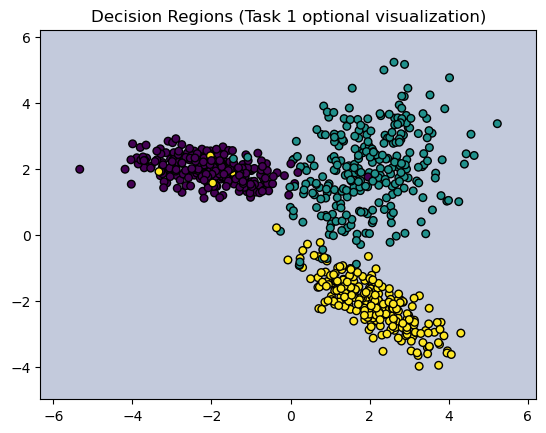

In [6]:
visualize_2d_decision_boundary(clf, syn_data['trainX'], syn_data['trainY'])
plt.show()

### Notes on bit budgets

- **Uniform Scalar Quantization (USQ):**  
  The simplest baseline scheme is to quantize each feature (e.g., image pixel) independently using the same number of bits `b`.  
  The total budget is then `B_tot = M * b` with `M = 784` (28×28).  
  Example: `B_TOT_LIST = [784, 1568, 2352]` corresponds to **1 / 2 / 3 bits per feature** under USQ.  
  However, you can assign different bit-depths to different features, which would allow you to reach even lower budgets (e.g., `b=0` for some features).

- **Other quantizers:**  
  If you use non-uniform scalar, companded, or vector quantization, this direct formula may not apply.  
  In those cases, interpret `B_tot` as your **total bits per image** based on your quantizer design  
  (e.g., sum of bits for transmitted indices, parameters, or blocks).  
  - **If you transmit selectively (e.g., only send clustered or informative samples):**  
  Report your budget as the **average total bits per image across the full dataset**,  
  not just the bits for transmitted samples. This ensures fair comparison with methods  
  that send every image.

  Be explicit in your report about how you compute and compare bit budgets.

- **Decentralized setting:**  
  Each sensor has `d_s = 196` features; a per-sensor budget `k` corresponds to a local bit constraint.  
  In USQ, this implies a local bit-depth `b_s ≈ floor(k / d_s)`;  
  in more general designs, `k` is simply the total bits that sensor `s` is allowed to send per image.

- **No-quantization reference:**  
  Original (uncompressed) features are the upper bound.  
  For an 8-bit scalar baseline: `784 * 8 = 6272` bits/image.

- **Compare apples-to-apples:**  
  Use the same total budgets (`B_TOT_LIST`) across centralized and decentralized experiments,  
  but remember that the mapping between bits and quantization precision may differ depending on your quantizer.

## Task 2 — Centralized compression
Uncomment the following once you've implemented `MyFeatureCompression.run_centralized`.

0
0
1
2
3
4


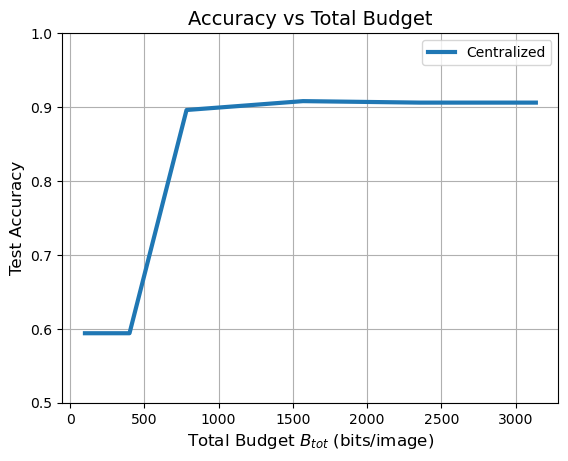

In [19]:
fc = MyFeatureCompression(K=3)
B_tot_list = [100, 400, 784, 1568, 2352, 3136]  # example budgets (you can modify)
res_central = fc.run_centralized(
    mnist_data['trainX'], mnist_data['trainY'],
    mnist_data['valX'],   mnist_data['valY'],
    mnist_data['testX'],  mnist_data['testY'],
    B_tot_list=B_tot_list,
)
plot_result_total(result2=res_central, result3_2=None)

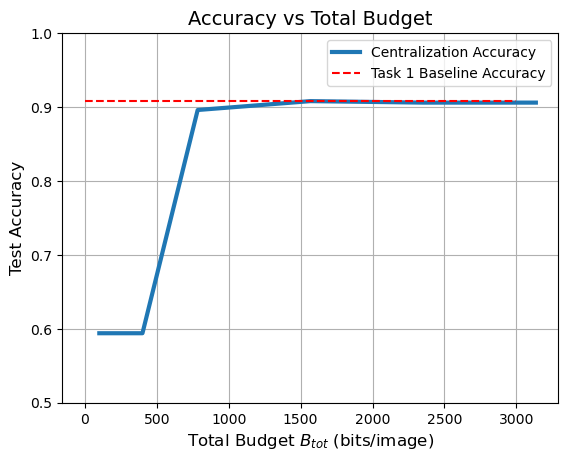

In [20]:
# above plot w/overlaid Task 1 Baseline Accuracy
result2=res_central
plt.plot(result2['B_tot'], result2['test_accuracy'], label='Centralization Accuracy', markersize=12, linewidth=3)
x = np.linspace(0,3000)
plt.plot(x, np.ones(50)*mnist_test_acc, 'r--', label = "Task 1 Baseline Accuracy")
plt.legend()
plt.ylim(0.5, 1)
plt.xlabel("Total Budget $B_{tot}$ (bits/image)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Accuracy vs Total Budget", fontsize=14)
plt.grid(True)
plt.show()

## Task 3.1 — Decentralized: fixed per-sensor budget
Uncomment the following once you've implemented `MyFeatureCompression.run_decentralized_per_sensor`.

In [9]:
fc = MyFeatureCompression(K=3)

In [10]:
I_train, Xtr_blocks = split_into_quadrants(mnist_data['trainX'])
_,       Xva_blocks = split_into_quadrants(mnist_data['valX'])
_,       Xte_blocks = split_into_quadrants(mnist_data['testX'])

In [11]:
I_train, Xtr_blocks = split_into_quadrants(mnist_data['trainX'])
_,       Xva_blocks = split_into_quadrants(mnist_data['valX'])
_,       Xte_blocks = split_into_quadrants(mnist_data['testX'])

k_list = [25, 100, 196, 392, 588, 784] # example budgets (you can modify)
res_k = fc.run_decentralized_per_sensor(
    Xtr_blocks, Xva_blocks, Xte_blocks,
    mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
    k_list=k_list,
)
res_k['baseline_test_accuracy_task1'] = mnist_test_acc
plot_result_per_sensor(result3_1=res_k)

0
0
1


KeyboardInterrupt: 

## Task 3.2 — Decentralized: total bit budget
Uncomment the following once you've implemented `MyFeatureCompression.run_decentralized_total`.

In [12]:
from scipy.cluster.vq import whiten
import random

In [13]:
def vector_quantize(image, cur_k):
    image = image.reshape([-1,1])
    whitened_image = whiten(image) # (784 , 1)
    code_book, clusters = kcluster(whitened_image, k = cur_k)
    image = image.flatten()
    for i in range(len(code_book)):
        cluster = clusters[i]
        for j in code_book[i]:
            image[j] = cluster[0]

    return image
    


def flattener(blocks):
    flattened_stacks = []
    for j in range(len(blocks[0])):
        quad0 = blocks[0][j].reshape(14,14)
        quad1 = blocks[1][j].reshape(14,14)
        quad2 = blocks[2][j].reshape(14,14)
        quad3 = blocks[3][j].reshape(14,14)

        stack1 = np.hstack([quad0, quad1])
        stack2 = np.hstack([quad2, quad3])
        stack3 = np.vstack([stack1, stack2])

        flattened_stacks.append(stack3.flatten())
    flattened_stacks = np.array(flattened_stacks)
    return flattened_stacks


####
# Source - https://stackoverflow.com/a
# Posted by junwangbuaa, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-29, License - CC BY-SA 3.0

#Manhattan Distance
def L1(v1,v2):
    if(len(v1)!=len(v2)):
        print("error")
        return -1
    return sum([abs(v1[i]-v2[i]) for i in range(len(v1))])

# kmeans with L1 distance. 
# rows refers to the NxM feature vectors
def kcluster(rows,distance=L1,k=4):# Cited from Programming Collective Intelligence 
    # Determine the minimum and maximum values for each point
    ranges=[(min([row[i] for row in rows]),max([row[i] for row in rows])) for i in range(len(rows[0]))]

    # Create k randomly placed centroids
    clusters=[[random.random( )*(ranges[i][1]-ranges[i][0])+ranges[i][0] for i in range(len(rows[0]))] for j in range(k)]

    lastmatches=None
    for t in range(10):
        #print("Iteration %d" % t)
        bestmatches=[[] for i in range(k)]
        # Find which centroid is the closest for each row
        for j in range(len(rows)):
            row=rows[j]
            bestmatch=0
            for i in range(k):
                d=distance(clusters[i],row)
                if d<distance(clusters[bestmatch],row): 
                    bestmatch=i
            bestmatches[bestmatch].append(j)
        ## If the results are the same as last time, this is complete
        if bestmatches==lastmatches:
            break
        lastmatches=bestmatches

        # Move the centroids to the average of their members
        for i in range(k):
            avgs=[0.0]*len(rows[0])
            if len(bestmatches[i])>0:
                for rowid in bestmatches[i]:
                    for m in range(len(rows[rowid])):
                        avgs[m]+=rows[rowid][m]
                for j in range(len(avgs)):
                    avgs[j]/=len(bestmatches[i])
                clusters[i]=avgs
    return bestmatches, clusters
####

In [ ]:
budgets = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

M = int(784/4) # 196

best_ratios = []
test_accuracy = 0.0
best_accuracy = 0.0
best_allocation = [0.0, 0.0, 0.0, 0.0]


train_blocks = Xtr_blocks
val_blocks = Xva_blocks
test_blocks = Xte_blocks
trainY = mnist_data['trainY']
valY = mnist_data['valY']
testY = mnist_data['testY']


In [ ]:


# figure out best accuracy for minimal bit budget, then extrapolate to remainder of bit budgets

for b0 in budgets:
    for b1 in budgets:
        for b2 in budgets:
            for b3 in budgets:
                if b0+b1+b2+b3 != 1.0:
                    continue

                # bits per feature
                b0_ = (B_tot_list[0] * b0)//M 
                b1_ = (B_tot_list[0] * b1)//M 
                b2_ = (B_tot_list[0] * b2)//M 
                b3_ = (B_tot_list[0] * b3)//M 

                bit_allocations = [b0_, b1_, b2_, b3_] # bits per feature per quadrant

                print(b0, b1, b2, b3)
                
                quantized_train_blocks = []
                for i in range(len(train_blocks)):
                    train_block = train_blocks[i]
                    cur_k = int((2**bit_allocations[i])) # bit depth (different per quadrant)
                    quantized_train_block = [vector_quantize(image, cur_k) for image in train_block]
                    quantized_train_blocks.append(quantized_train_block)
                
                
                quantized_val_blocks = []
                for i in range(len(val_blocks)):
                    val_block = val_blocks[i]
                    cur_k = int((2**bit_allocations[i])) # bit depth (different per quadrant)
                    quantized_val_block = [vector_quantize(image, cur_k) for image in val_block]
                    quantized_val_blocks.append(quantized_val_block)
                
                flattened_train = flattener(np.array(quantized_train_blocks))
                flattened_val = flattener(np.array(quantized_val_blocks))

                clf = MyDecentralized(K=3)
                clf.train(flattened_train, trainY)
                test_accuracy = clf.evaluate(flattened_val, valY)

                if test_accuracy > best_accuracy:
                    best_ratios = [b0, b1, b2, b3]       
                    best_accuracy = test_accuracy

final_accuracies = []
for j in range(len(B_tot_list)):
    best_allocations = np.array(best_ratios)*B_tot_list[j]
    print(best_allocations)

    quantized_train_blocks = []
    for i in range(len(train_blocks)):
        
        train_block = train_blocks[i]
        cur_k = int((2**best_allocations[i])) # bit depth (different per quadrant)
        quantized_train_block = [vector_quantize(image, cur_k) for image in train_block]
        quantized_train_blocks.append(quantized_train_block)

    quantized_test_blocks = []
    for i in range(len(test_blocks)):
        test_block = test_blocks[i]
        cur_k = int((2**best_allocations[i])) # bit depth (different per quadrant)
        quantized_test_block = [vector_quantize(image, cur_k) for image in test_block]
        quantized_test_blocks.append(quantized_test_block)


    flattened_train = flattener(quantized_train_blocks)
    flattened_test = flattener(quantized_test_blocks)

    clf = MyDecentralized(K=3)
    clf.train(flattened_train, trainY)
    final_accuracies.append(clf.evaluate(flattened_test, testY))

0.1 0.1 0.1 0.7
[0.0, 0.0, 0.0, 0.0]


KeyboardInterrupt: 

In [57]:
print(bit_allocations)

[0.0, 0.0, 0.0, 0.0]


In [53]:
quantized_train_blocks = []
for i in range(len(train_blocks)):
    print(i)
    train_block = train_blocks[i]
    print(np.shape(train_block))
    quantized_train_block = [vector_quantize(image, int((2**bit_allocations[i]))) for image in train_block]
    print(quantized_train_block)
    quantized_train_blocks.append(quantized_train_block)

0
(800, 196)
[array([0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 2.01051089, 2.01051089, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       2.01051089, 2.01051089, 2.01051089, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 2.01051089, 2.01051089,
       2.01051089, 2.01051089, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 2.01051089, 2.01051089, 2.01051089, 2.01051089,
       2.01051089, 0.05217293, 0.05217293, 0.05217293, 0.05217293,
       0.05217293, 0.05217293, 0.05217293, 2.01051089, 2.01051089,
       2.01051089, 2.01051089, 2.01051089, 2.01051089, 2.01051089,
       0.05217293, 0.05217293, 0.05217293, 0.052

KeyboardInterrupt: 

In [31]:
B_tot_list = [100, 400, 784, 1568, 2352, 3136]  # example budgets (you can modify)
res_B = fc.run_decentralized_total(
    Xtr_blocks, Xva_blocks, Xte_blocks,
    mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
    B_tot_list=B_tot_list,
)
plot_result_total(result2=None, result3_2=res_B)

0.1 0.1 0.1 0.7
0.1 0.1 0.2 0.6
0.1 0.1 0.3 0.5
0.1 0.1 0.4 0.4
0.1 0.1 0.5 0.3
0.1 0.1 0.6 0.2
0.1 0.2 0.1 0.6
0.1 0.2 0.2 0.5
0.1 0.2 0.3 0.4
0.1 0.2 0.4 0.3
0.1 0.2 0.5 0.2
0.1 0.2 0.6 0.1
0.1 0.3 0.1 0.5
0.1 0.3 0.2 0.4
0.1 0.3 0.3 0.3
0.1 0.3 0.4 0.2
0.1 0.3 0.5 0.1
0.1 0.4 0.1 0.4
0.1 0.4 0.2 0.3
0.1 0.4 0.3 0.2
0.1 0.4 0.4 0.1
0.1 0.5 0.1 0.3
0.1 0.5 0.2 0.2
0.1 0.6 0.1 0.2
0.2 0.1 0.1 0.6
0.2 0.1 0.2 0.5
0.2 0.1 0.3 0.4
0.2 0.1 0.4 0.3
0.2 0.1 0.5 0.2
0.2 0.1 0.6 0.1
0.2 0.2 0.1 0.5
0.2 0.2 0.2 0.4
0.2 0.2 0.3 0.3
0.2 0.2 0.4 0.2
0.2 0.2 0.5 0.1
0.2 0.3 0.1 0.4
0.2 0.3 0.2 0.3
0.2 0.3 0.3 0.2
0.2 0.3 0.4 0.1
0.2 0.4 0.1 0.3
0.2 0.4 0.2 0.2
0.2 0.5 0.1 0.2
0.2 0.6 0.1 0.1
0.3 0.1 0.1 0.5
0.3 0.1 0.2 0.4
0.3 0.1 0.3 0.3
0.3 0.1 0.4 0.2
0.3 0.1 0.5 0.1
0.3 0.2 0.1 0.4
0.3 0.2 0.2 0.3
0.3 0.2 0.3 0.2
0.3 0.2 0.4 0.1
0.3 0.3 0.1 0.3
0.3 0.3 0.2 0.2
0.3 0.4 0.1 0.2
0.3 0.5 0.1 0.1
0.4 0.1 0.1 0.4
0.4 0.1 0.2 0.3
0.4 0.1 0.3 0.2
0.4 0.1 0.4 0.1
0.4 0.2 0.1 0.3
0.4 0.2 0.2 0.2
0.4 0.3 

KeyboardInterrupt: 

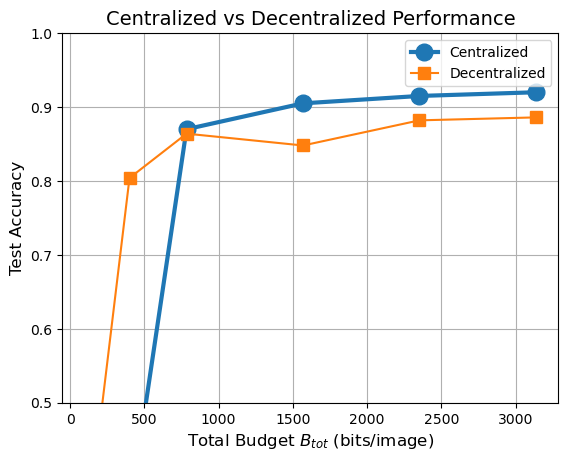

In [ ]:
# overlay centralized vs decentralized
res_compare = {
    'centralized':   res_central,
    'decentralized': res_B,
}
plot_result_centralized_vs_decentralized(result=res_compare)

## Task 3.3 — Minimal bits for target accuracy
Uncomment once you've implemented `MyTargetAllocator` methods.

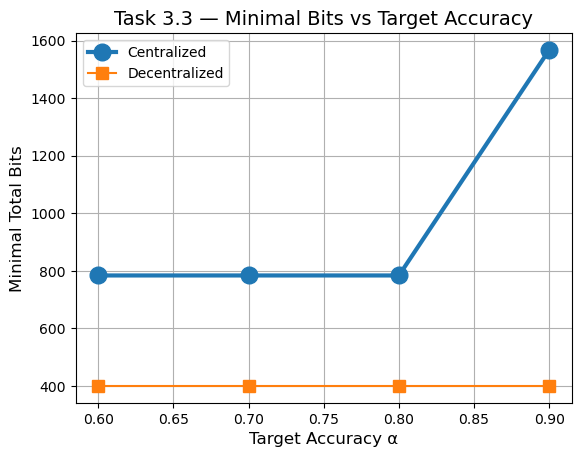

In [ ]:
ta = MyTargetAllocator(K=3)
alphas = [0.6, 0.7, 0.8, 0.9]  # or choose based on your curves
B_grid = [100, 400, 784, 1568, 2352, 3136]  # example budgets (you can modify)
cent_min = []
decz_min = []
for a in alphas:
    Bc = ta.minimal_bits_centralized(fc, mnist_data['trainX'], mnist_data['trainY'],
                                     mnist_data['valX'],   mnist_data['valY'],
                                     mnist_data['testX'],  mnist_data['testY'],
                                     alpha=a, B_grid=B_grid)
    Bd, alloc = ta.minimal_bits_decentralized(fc, Xtr_blocks, Xva_blocks, Xte_blocks,
                                              mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
                                              alpha=a, B_grid=B_grid)
    cent_min.append(Bc)
    decz_min.append(Bd)
res_target = {'alphas': alphas, 'centralized_min_bits': cent_min, 'decentralized_min_bits': decz_min}
plot_result_target(result=res_target)

## Mock results (for plotting format only)

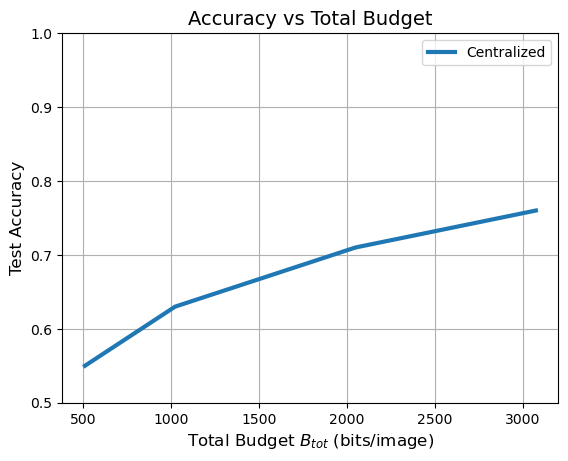

In [ ]:
# --- Task 2 (centralized) mock ---
mock_res_central = {
    'B_tot': [512, 1024, 2048, 3072],
    'test_accuracy': [0.55, 0.63, 0.71, 0.76],
}
plot_result_total(result2=mock_res_central, result3_2=None)

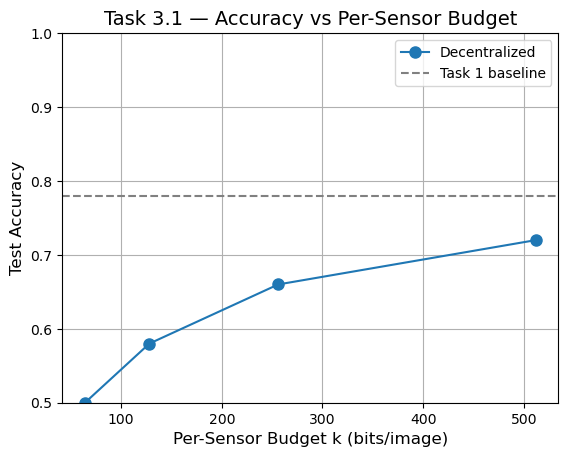

In [ ]:
# --- Task 3.1 (per-sensor) mock ---
mock_res_k = {
    'k': [64, 128, 256, 512],
    'test_accuracy': [0.50, 0.58, 0.66, 0.72],
    'baseline_test_accuracy_task1': 0.78,
    'b_s': [(0,0,0,0),(1,1,1,1),(2,2,2,2),(4,4,4,4)],
}
plot_result_per_sensor(result3_1=mock_res_k)

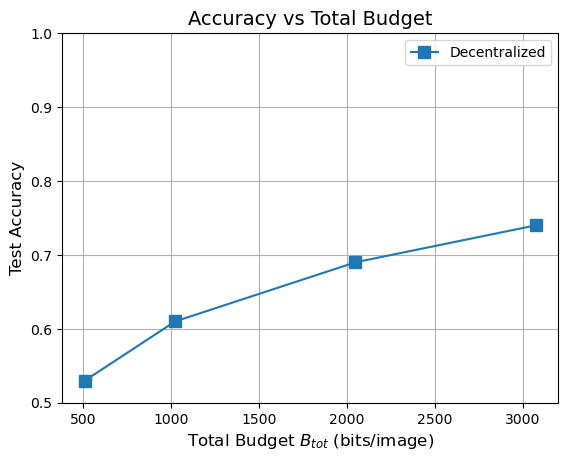

In [ ]:
# --- Task 3.2 (total budget) mock ---
mock_res_B = {
    'B_tot': [512, 1024, 2048, 3072],
    'test_accuracy': [0.53, 0.61, 0.69, 0.74],
    'best_allocation': [(0,2,2,2),(1,1,2,2),(2,2,2,2),(3,3,2,2)],
}
plot_result_total(result2=None, result3_2=mock_res_B)

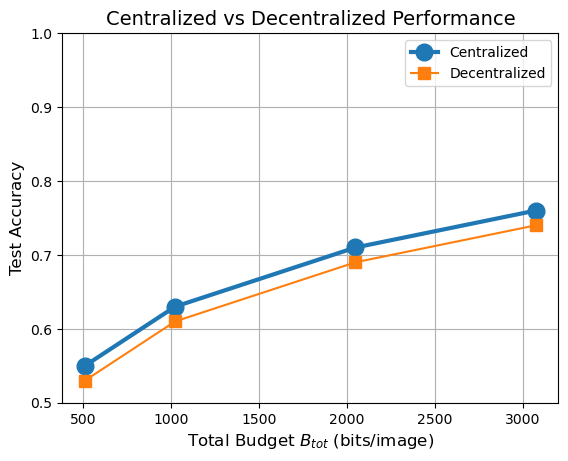

In [ ]:
# --- Centralized vs Decentralized overlay (mock) ---
plot_result_centralized_vs_decentralized(result={
    'centralized': mock_res_central,
    'decentralized': mock_res_B,
})

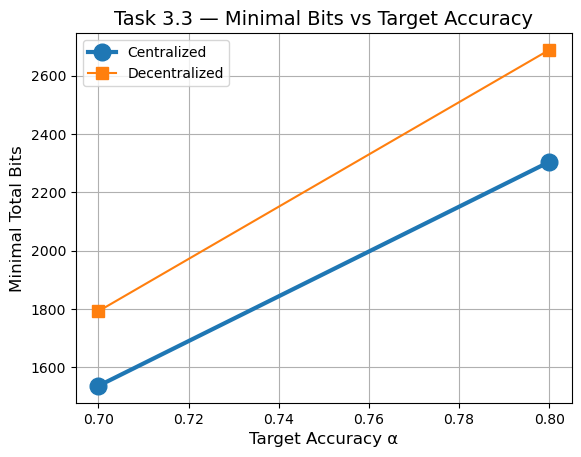

In [ ]:
# --- Task 3.3 (target accuracy) mock ---
mock_res_target = {
    'alphas': [0.7, 0.8, 0.9],
    'centralized_min_bits': [1536, 2304, None],
    'decentralized_min_bits': [1792, 2688, None],
}
plot_result_target(result=mock_res_target)